# MCMC Sample Loading and Plots

Load a saved MCMC sample text file and recreate the plots in-notebook so you can tweak formatting.

In [17]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

# Resolve project root robustly
cwd = Path.cwd()
if (cwd / "bayesian-binary-masses").exists():
    project_root = cwd / "bayesian-binary-masses"
elif cwd.name == "bayesian-binary-masses":
    project_root = cwd
elif "bayesian-binary-masses" in cwd.parts:
    idx = cwd.parts.index("bayesian-binary-masses")
    project_root = Path(*cwd.parts[: idx + 1])
else:
    project_root = cwd

src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from binary_masses.differencepoly_feh import IsochroneMassSurfaceModel, DifferencePolyFehMLR


In [8]:
# Paths and parameters (edit these as needed)
results_dir = project_root / "results" / "test_diffpoly_feh"
sample_path = results_dir / "mcmc_model-differencepolyfeh_unc-rice_fehcont_outlierfit_order2_feh[-1.00,+0.60].txt"
corner_out = results_dir / "corner_model-differencepolyfeh_unc-rice_fehcont_outlierfit_order2_feh[-1.00,+0.60].png"
fit_multifeh_out = results_dir / "fit_multifeh_model-differencepolyfeh_unc-rice_fehcont_outlierfit_order2_feh[-1.00,+0.60].png"

data_path = project_root / "data" / "jd_single_1kpc_filtered.fits"
iso_data_dir = project_root / "data" / "interpolated_mass_data"
feh_column = "feh"

order = 2
uncertainty_model = "rice"
feh_min = -1.0
feh_max = 0.6
absg_min = 3.5
absg_max = 14.0
mass_min = 0.05
mass_max = 2.0
deriv_penalty_strength = 10.0
coeff_prior_scale = 5.0
feh_coeff_prior_scale = 1.0
fit_outlier_params = True
outlier_kappa = None
outlier_kappa_scale = 1.0

feh_plot_values = [-1.0, -0.5, 0.0, 0.3, 0.6]

# Optional: drop fixed params from corner plot
drop_param_names = ["b_1", "b_2"]
drop_param_indices = []  # 0-based indices if no labels are available

sample_path, corner_out, fit_multifeh_out


(PosixPath('/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/results/test_diffpoly_feh/mcmc_model-differencepolyfeh_unc-rice_fehcont_outlierfit_order2_feh[-1.00,+0.60].txt'),
 PosixPath('/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/results/test_diffpoly_feh/corner_model-differencepolyfeh_unc-rice_fehcont_outlierfit_order2_feh[-1.00,+0.60].png'),
 PosixPath('/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/results/test_diffpoly_feh/fit_multifeh_model-differencepolyfeh_unc-rice_fehcont_outlierfit_order2_feh[-1.00,+0.60].png'))

In [9]:
# Load the MCMC samples
try:
    samples = np.loadtxt(sample_path)
    df = None
except Exception:
    # Fallback for whitespace/CSV with headers
    df = pd.read_csv(sample_path, comment="#", delim_whitespace=True)
    samples = df.values

samples.shape


(5000, 9)

In [10]:
# Optional: load data (used for reference [Fe/H] or truth scatter)
try:
    from astropy.table import Table
    data = Table.read(data_path)
except Exception as exc:
    data = None
    print(f"Could not read data: {exc}")

# Optional: load isochrone surface
try:
    iso_surface = IsochroneMassSurfaceModel.from_interpolated_mass_data(
        iso_data_dir,
        mass_min=mass_min,
    )
except Exception as exc:
    iso_surface = None
    print(f"Could not load isochrone surface: {exc}")

data is not None, iso_surface is not None


(True, True)

In [11]:
# Build a fitter instance and attach samples (no re-sampling)
fitter = DifferencePolyFehMLR(
    order=order,
    isochrone_surface_model=iso_surface,
    feh_min=feh_min,
    feh_max=feh_max,
    mass_min=mass_min,
    mass_max=mass_max,
    absg_min=absg_min,
    absg_max=absg_max,
    uncertainty_model=uncertainty_model,
    f_outlier=0.1,
    outlier_u0=30,
    outlier_sigma=15,
    outlier_kappa=outlier_kappa,
    outlier_kappa_scale=outlier_kappa_scale,
    fit_outlier_params=fit_outlier_params,
    deriv_penalty_strength=deriv_penalty_strength,
    coeff_prior_scale=coeff_prior_scale,
    feh_coeff_prior_scale=feh_coeff_prior_scale,
)

fitter.samples = samples

# Optional: set a default feh reference for single-metallicity plots
if data is not None and feh_column in data.colnames:
    fitter.feh_plot = float(np.nanmedian(np.array(data[feh_column], dtype=float)))
else:
    fitter.feh_plot = 0.0

fitter


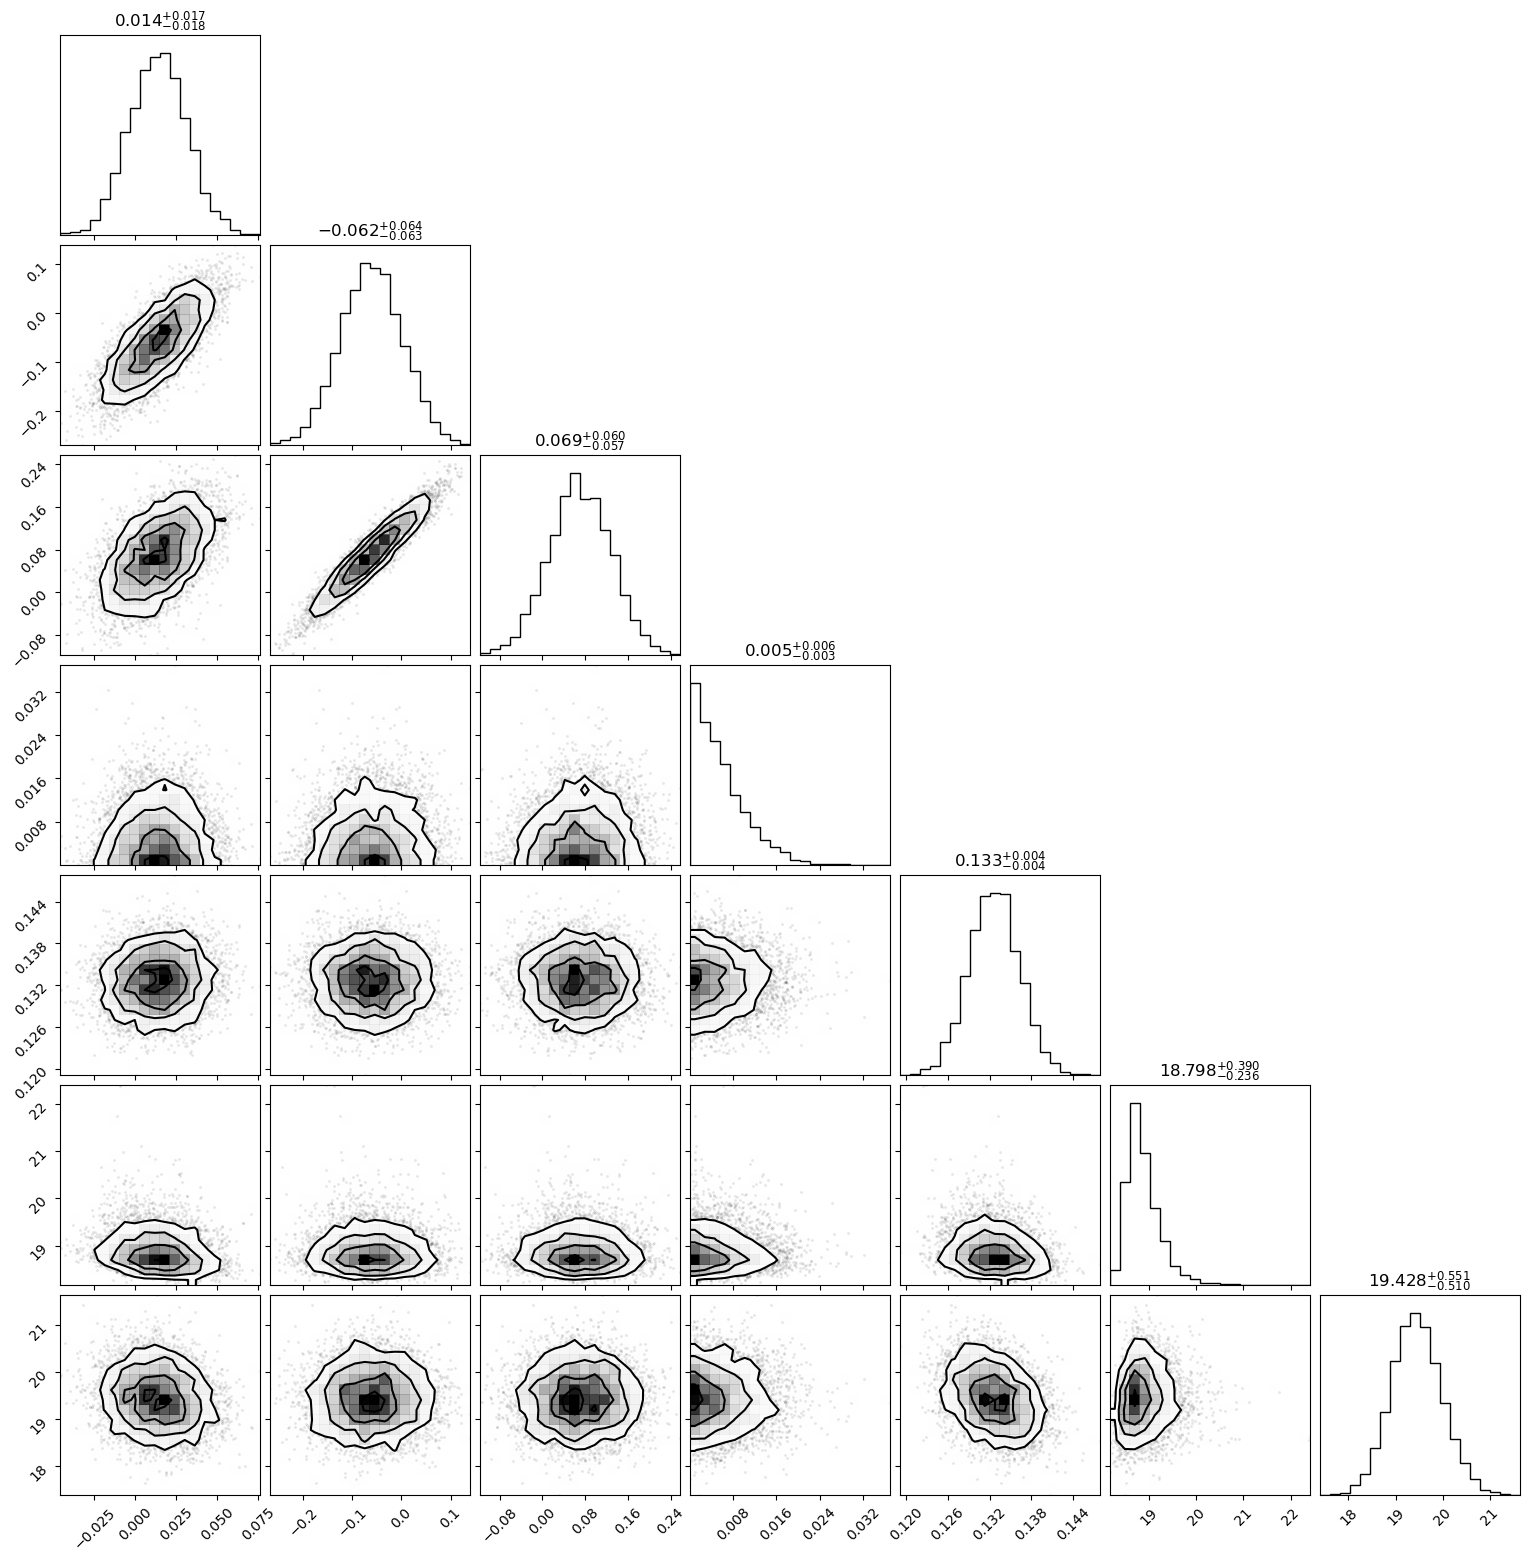

In [15]:
# Corner plot (edit corner kwargs freely)
labels = None
if df is not None:
    labels = list(df.columns)

plot_samples = samples
plot_labels = labels

# Drop parameters with zero dynamic range or user-specified masks
keep_mask = np.ones(plot_samples.shape[1], dtype=bool)
for idx in range(plot_samples.shape[1]):
    col = plot_samples[:, idx]
    if not np.isfinite(col).any():
        keep_mask[idx] = False
        continue
    if np.nanmax(col) == np.nanmin(col):
        keep_mask[idx] = False

if plot_labels is not None and drop_param_names:
    for i, name in enumerate(plot_labels):
        if name in drop_param_names:
            keep_mask[i] = False

if drop_param_indices:
    for i in drop_param_indices:
        if 0 <= i < keep_mask.size:
            keep_mask[i] = False

if not np.all(keep_mask):
    plot_samples = plot_samples[:, keep_mask]
    if plot_labels is not None:
        plot_labels = [plot_labels[i] for i in range(len(plot_labels)) if keep_mask[i]]

fig = corner.corner(plot_samples, labels=plot_labels, show_titles=True, title_fmt='.3f')
# fig.savefig(corner_out, dpi=200, bbox_inches=tight)


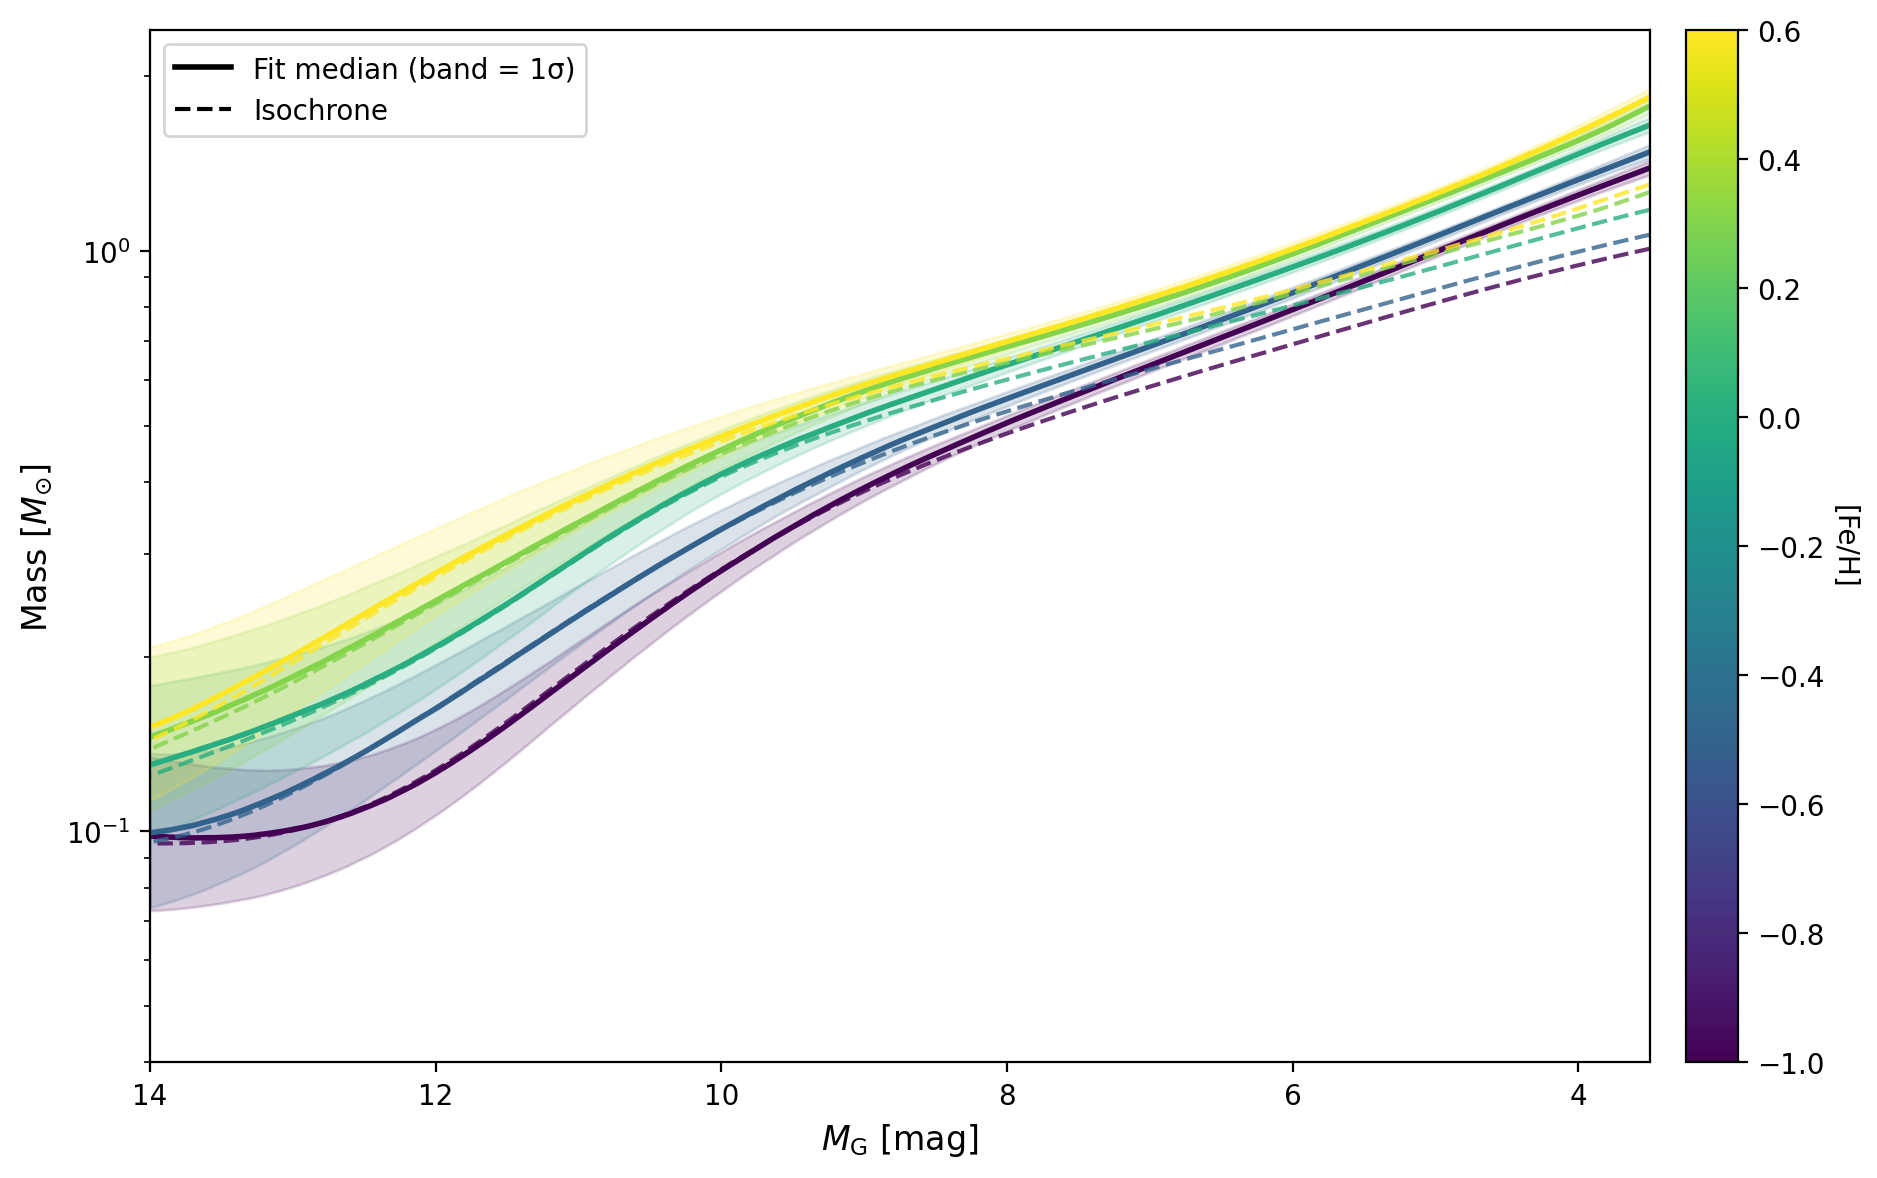

In [18]:
# Multi-[Fe/H] fit plot (edit style freely)
if fitter.samples is None or fitter.samples.size == 0:
    raise ValueError("No samples loaded.")

if fitter.fit_outlier_params:
    coeff_samples = fitter.samples[:, :-3]
else:
    coeff_samples = fitter.samples

num_samples = min(2000, len(coeff_samples))
if num_samples < len(coeff_samples):
    rng = np.random.default_rng(42)
    indices = rng.choice(len(coeff_samples), size=num_samples, replace=False)
    coeff_samples = coeff_samples[indices]

absg_range = np.linspace(absg_min, absg_max, 600)
feh_values = np.asarray(feh_plot_values, dtype=float)
feh_values = np.sort(feh_values[np.isfinite(feh_values)])
if feh_values.size == 0:
    raise ValueError("feh_plot_values must contain at least one finite value.")

cmap = plt.cm.viridis
norm = plt.Normalize(feh_values.min(), feh_values.max())

fig, ax = plt.subplots(figsize=(10, 6))

for feh in feh_values:
    color = cmap(norm(feh))
    masses = fitter.mass_from_absg_feh(absg_range, feh, coeff_samples)
    lower, median, upper = np.percentile(masses, [16, 50, 84], axis=0)

    ax.fill_between(absg_range, lower, upper, color=color, alpha=0.18)
    ax.plot(absg_range, median, color=color, linewidth=2)

    if iso_surface is not None:
        iso_mass = iso_surface.mass_from_absg_mh(absg_range, feh)
        ax.plot(absg_range, iso_mass, color=color, linewidth=1.5, linestyle="--", alpha=0.8)

legend_lines = [
    Line2D([0], [0], color="black", linewidth=2, linestyle="-"),
    Line2D([0], [0], color="black", linewidth=1.5, linestyle="--"),
]
ax.legend(legend_lines, ["Fit median (band = 1σ)", "Isochrone"], fontsize=10, loc="best")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("[Fe/H]", rotation=270, labelpad=12)

ax.set_xlabel("$M_{\\mathrm{G}}$ [mag]", fontsize=12)
ax.set_ylabel("Mass [$M_{\\odot}$]", fontsize=12)
ax.set_xlim(absg_min, absg_max)
ax.set_ylim(fitter.mass_min * 0.8, fitter.mass_max * 1.2)
ax.set_yscale("log")
ax.invert_xaxis()
plt.tight_layout()
plt.show()
# fit_multifeh_out.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(fit_multifeh_out, dpi=300, bbox_inches="tight")

